# Exploritary Data Analysis On Stroke Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew,kurtosis

In [16]:
df=pd.read_csv('stroke-data.csv')

In [17]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [18]:
df=df.drop(columns=['id'])
# beacause we no need of id column for EDA

In [19]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [7]:
df.shape

(5110, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [8]:
df.size

56210

In [9]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Univariate Analysis

### Univariate Analysis on  gender

In [10]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [11]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [12]:
df['gender']=df['gender'].str.replace('Other','Female',regex=True)

In [13]:
df['gender'].value_counts()

gender
Female    2995
Male      2115
Name: count, dtype: int64

<Axes: xlabel='gender'>

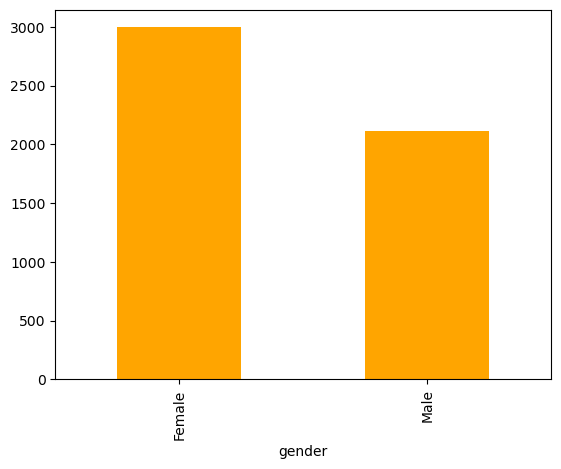

In [14]:
df['gender'].value_counts().plot(kind='bar',color='orange')

In [15]:
a=df[(df['gender']=='Male')&(df['stroke']==1)].shape[0]
b=df[(df['gender']=='Female')&(df['stroke']==1)].shape[0]
total=df.shape[0]

mp=(a/total)*100
fp=(b/total)*100
print(mp,fp)

2.1135029354207435 2.759295499021526


In [16]:
a,b

(108, 141)

### Univariate Analysis on age

In [17]:
df['age'].isna().sum()

0

#### statistical univariate analysis on age

In [18]:
df['age'].mean()

43.226614481409

In [19]:
df['age'].median()

45.0

In [20]:
df['age'].std()

22.61264672311352

In [21]:
df['age'].max()

82.0

In [22]:
df['age'].min()

0.08

In [23]:
percentiles=[0,10,25,50,75,90,95,99,100]

for i in percentiles:
    percentile_values=np.percentile(df['age'],i)
    print(f'{i}th Percentile Value : {percentile_values}')

0th Percentile Value : 0.08
10th Percentile Value : 11.0
25th Percentile Value : 25.0
50th Percentile Value : 45.0
75th Percentile Value : 61.0
90th Percentile Value : 75.0
95th Percentile Value : 79.0
99th Percentile Value : 82.0
100th Percentile Value : 82.0


#### Graphical univariate analysis on age

C:\Users\AKASH\AppData\Local\Temp\ipykernel_22944\3234920688.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


<Axes: xlabel='age', ylabel='Density'>

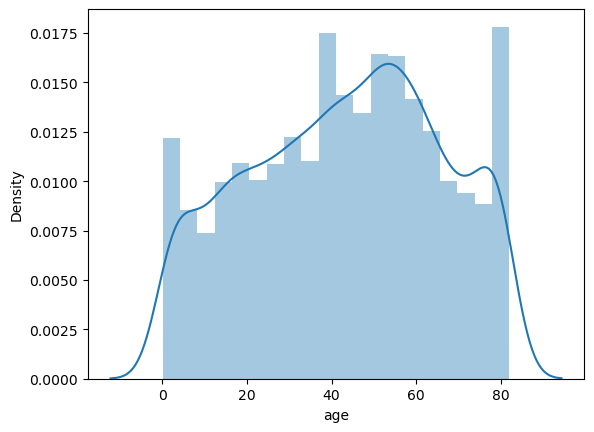

In [24]:
sns.distplot(df['age'])

In [25]:
skew(df['age'])

-0.1370190866396024

In [26]:
kurtosis(df['age'])

-0.9912147700517671

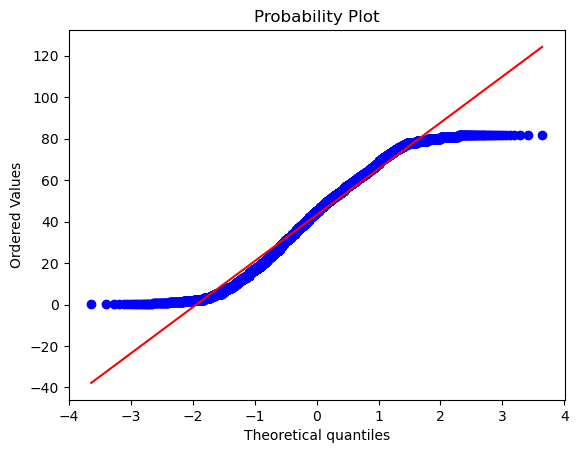

In [27]:
stats.probplot(df['age'],dist='norm',plot=plt)
plt.show()

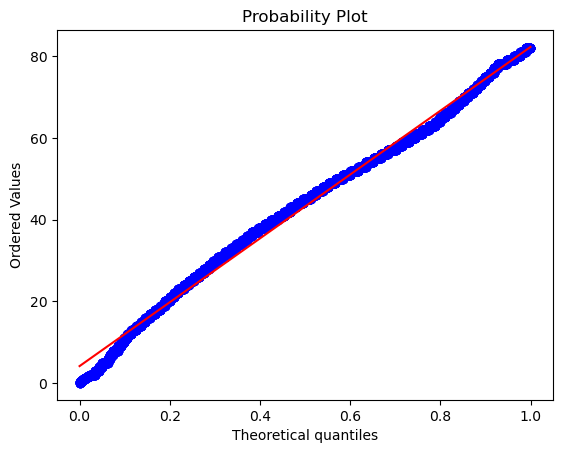

In [28]:
stats.probplot(df['age'],dist='uniform',plot=plt)
plt.show()

<Axes: ylabel='age'>

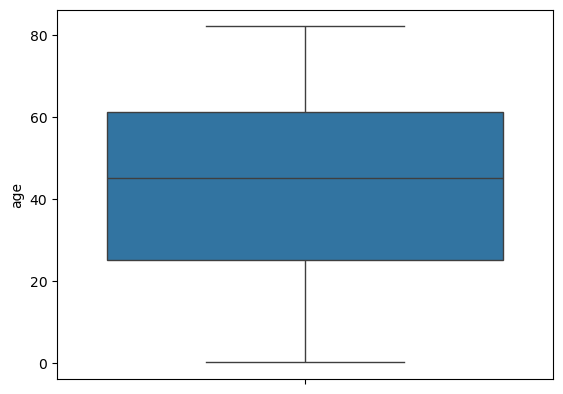

In [29]:
sns.boxplot(df['age'])

Text(0, 0.5, 'Cummilative Frequency')

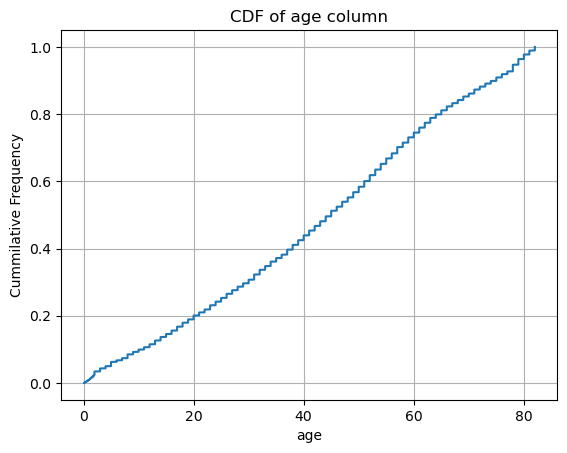

In [30]:
# construct CDF
sorted_val=df['age'].sort_values()
cdf_values=np.arange(1,len(sorted_val)+1)/len(sorted_val)

plt.plot(sorted_val,cdf_values)
plt.grid()
plt.title('CDF of age column')
plt.xlabel('age')
plt.ylabel('Cummilative Frequency')

In [31]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Univariate Analysis on hypertension

In [32]:
df['hypertension'].unique()

array([0, 1], dtype=int64)

In [33]:
df['hypertension'].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

<Axes: xlabel='hypertension'>

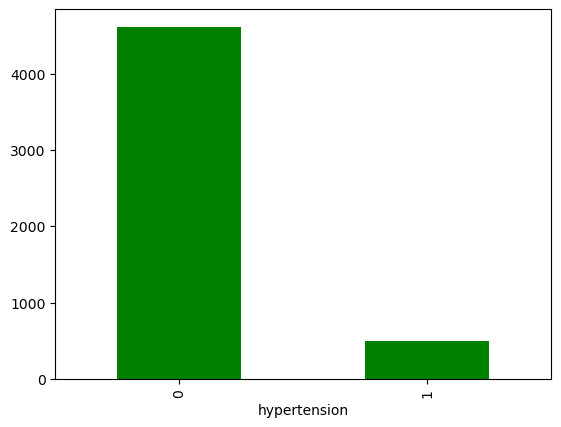

In [34]:
df['hypertension'].value_counts().plot(kind='bar',color='green')

In [43]:
a=df[(df['stroke']==1)&(df['hypertension']==1)].shape[0]
b=df[(df['stroke']==0)&(df['hypertension']==1)].shape[0]
total=df.shape[0]

mp=(a/total)*100
fp=(b/total)*100
print(mp,fp)

1.2915851272015655 8.454011741682974


In [ ]:
a=df[(df['gender']=='Male')&(df['hypertension']==1)].shape[0]
b=df[(df['gender']=='Female')&(df['hypertension']==1)].shape[0]
total=df.shape[0]

mp=(a/total)*100
fp=(b/total)*100
print(mp,fp)

In [36]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Univariate Analysis on heart_disease

In [37]:
df['heart_disease'].unique()

array([1, 0], dtype=int64)

In [38]:
df['heart_disease'].value_counts()

heart_disease
0    4834
1     276
Name: count, dtype: int64

<Axes: xlabel='heart_disease'>

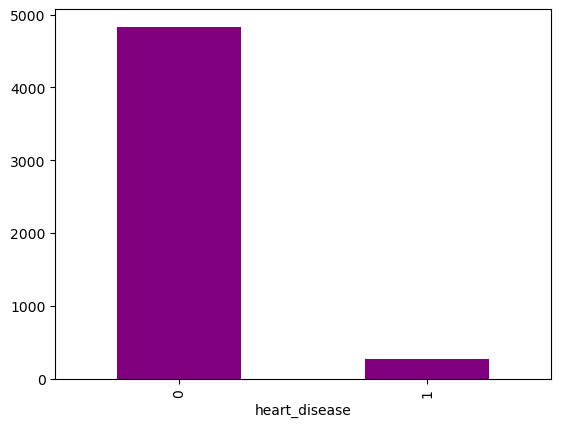

In [39]:
df['heart_disease'].value_counts().plot(kind='bar',color='purple')

In [40]:
a=df[(df['heart_disease']==1)&(df['stroke']==1)].shape[0]
total=df.shape[0]

sp=(a/total)*100
sp

0.9197651663405088

### Univariate Analysis on ever_married

In [41]:
df['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [42]:
df['ever_married'].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

<Axes: xlabel='ever_married'>

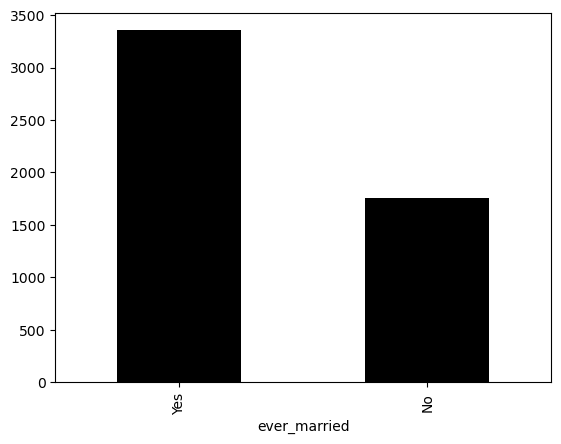

In [43]:
df['ever_married'].value_counts().plot(kind='bar',color='black')

In [44]:
a=df[(df['ever_married']=='Yes')&(df['hypertension']==1)].shape[0]
b=df[(df['ever_married']=='No')&(df['hypertension']==1)].shape[0]
total=df.shape[0]

ms=(a/total)*100
mn=(b/total)*100
print(ms,mn)

8.708414872798434 1.0371819960861057


In [45]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Univariate Analysis on work_type

In [46]:
df['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [47]:
df['work_type'].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

<Axes: xlabel='work_type'>

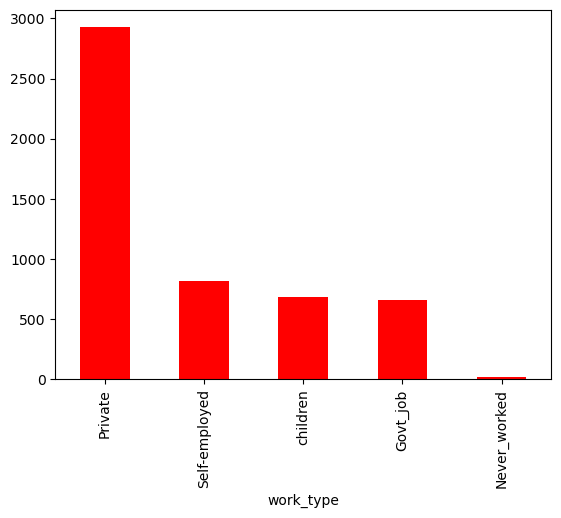

In [48]:
df['work_type'].value_counts().plot(kind='bar',color='red')

In [49]:
a=df[(df['work_type']=='Private')&(df['stroke']==1)].shape[0]
b=df[(df['work_type']=='Self-employed')&(df['stroke']==1)].shape[0]
c=df[(df['work_type']=='Govt_job')&(df['stroke']==1)].shape[0]
d=df[(df['work_type']=='children')&(df['stroke']==1)].shape[0]
e=df[(df['work_type']=='Never_worked')&(df['stroke']==1)].shape[0]

total=df.shape[0]

wp=(a/total)*100
ws=(b/total)*100
wg=(c/total)*100
wc=(d/total)*100
wn=(e/total)*100
print(wp,ws,wg,wc,wn)

2.9158512720156557 1.2720156555772992 0.6457925636007827 0.03913894324853229 0.0


#### Univariate Analysis on Residence_type

In [50]:
df['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [51]:
df['Residence_type'].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

<Axes: xlabel='Residence_type'>

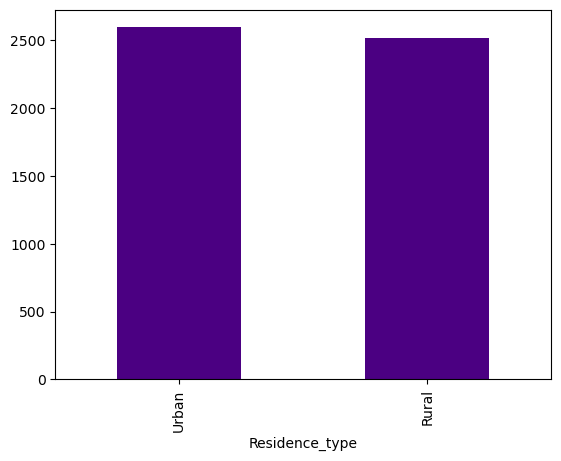

In [52]:
df['Residence_type'].value_counts().plot(kind='bar',color='indigo')

In [53]:
a=df[(df['Residence_type']=='Urban')&(df['stroke']==1)].shape[0]
b=df[(df['Residence_type']=='Rural')&(df['stroke']==1)].shape[0]
total=df.shape[0]
print(a,b)
ru=(a/total)*100
rr=(b/total)*100
print(ru,rr)

135 114
2.6418786692759295 2.2309197651663406


In [54]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


#### Univariate Analysis on avg_glucose_level	

In [55]:
df['avg_glucose_level'].isna().sum()
# there are no null values

0

In [56]:
df['avg_glucose_level'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5110 entries, 0 to 5109
Series name: avg_glucose_level
Non-Null Count  Dtype  
--------------  -----  
5110 non-null   float64
dtypes: float64(1)
memory usage: 40.1 KB


##### statistical analysis on avg_glucose_level

In [57]:
df['avg_glucose_level'].mean()

106.1476771037182

In [58]:
df['avg_glucose_level'].std()

45.28356015058203

In [59]:
df['avg_glucose_level'].median()

91.88499999999999

In [60]:
df['avg_glucose_level'].max()

271.74

In [61]:
df['avg_glucose_level'].min()

55.12

In [62]:
percentiles=[0,10,25,50,75,90,95,99,100]

for i in percentiles:
    percentile_values=np.percentile(df['avg_glucose_level'],i)
    print(f'{i}th Percentile Value : {percentile_values}')

0th Percentile Value : 55.12
10th Percentile Value : 65.789
25th Percentile Value : 77.245
50th Percentile Value : 91.88499999999999
75th Percentile Value : 114.09
90th Percentile Value : 192.18100000000007
95th Percentile Value : 216.29450000000003
99th Percentile Value : 240.7082
100th Percentile Value : 271.74


#### graphical analysis on avg_glucose_level

C:\Users\AKASH\AppData\Local\Temp\ipykernel_22944\3535339131.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['avg_glucose_level'])


<Axes: xlabel='avg_glucose_level', ylabel='Density'>

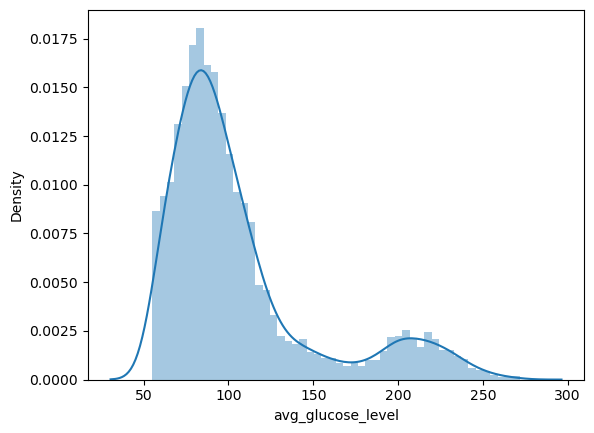

In [63]:
sns.distplot(df['avg_glucose_level'])

In [64]:
skew(df['avg_glucose_level'])

1.571822297397199

In [65]:
kurtosis(df['avg_glucose_level'])

1.6776607484156187

((array([-3.6412931, -3.4063133, -3.2768215, ...,  3.2768215,  3.4063133,
          3.6412931]),
  array([ 55.12,  55.22,  55.23, ..., 267.61, 267.76, 271.74])),
 (40.67894592510064, 106.1476771037182, 0.8978160806829297))

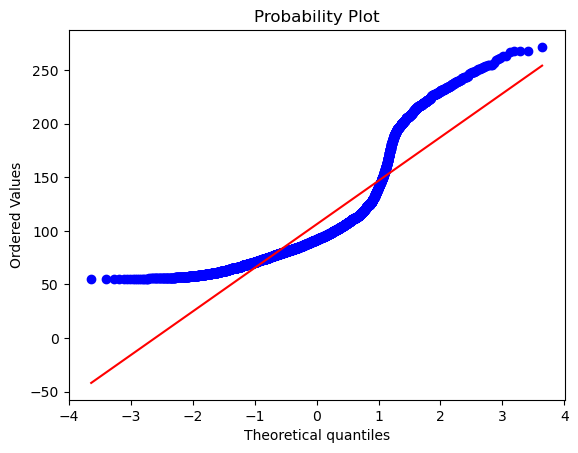

In [66]:
stats.probplot(df['avg_glucose_level'],dist='norm',plot=plt)

((array([1.35636041e-04, 3.29232843e-04, 5.24913582e-04, ...,
         9.99475086e-01, 9.99670767e-01, 9.99864364e-01]),
  array([ 55.12,  55.22,  55.23, ..., 267.61, 267.76, 271.74])),
 (136.13187914121625, 38.08173753311007, 0.8678409151367821))

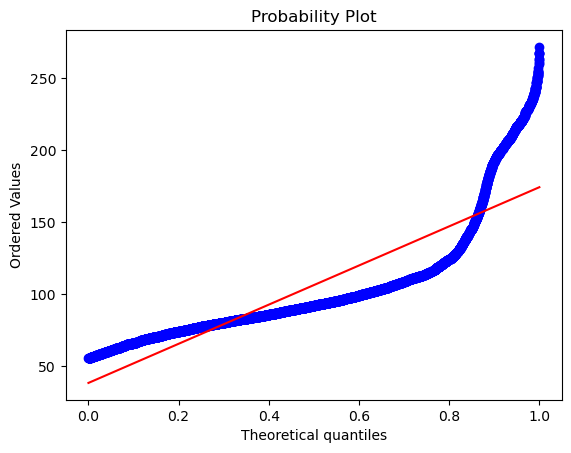

In [67]:
stats.probplot(df['avg_glucose_level'],dist='uniform',plot=plt)

((array([-3.6412931, -3.4063133, -3.2768215, ...,  3.2768215,  3.4063133,
          3.6412931]),
  array([4.00951263, 4.01132521, 4.01150628, ..., 5.5895307 , 5.59009106,
         5.60484573])),
 (0.3481224299431639, 4.592465422017301, 0.9611687615072549))

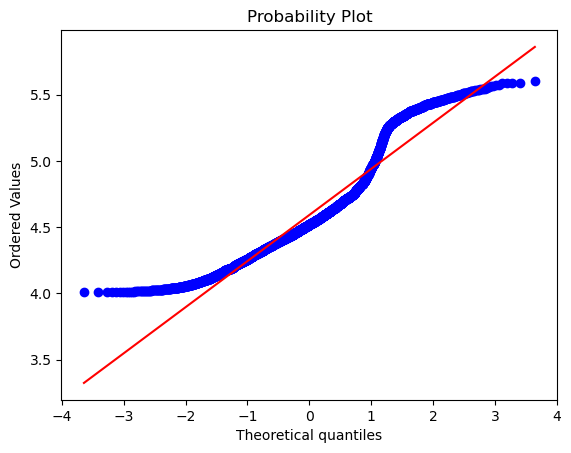

In [68]:
a=np.log(df['avg_glucose_level'])
stats.probplot(a,dist='norm',plot=plt)

-> avg_glucose_level is not at all a guassian or uniform or log normal so let tranform it into gaussian 

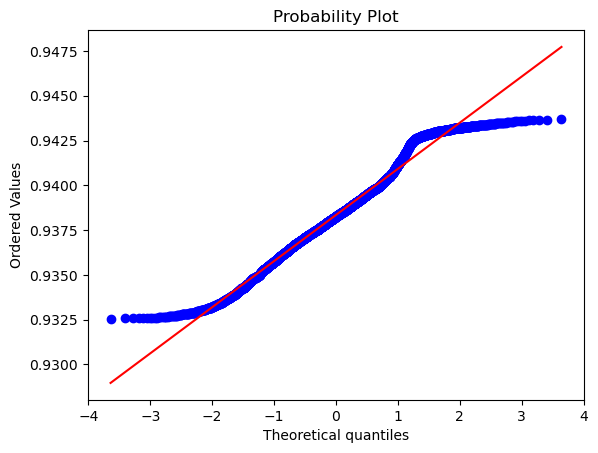

C:\Users\AKASH\AppData\Local\Temp\ipykernel_22944\2336267372.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(aa)


<Axes: ylabel='Density'>

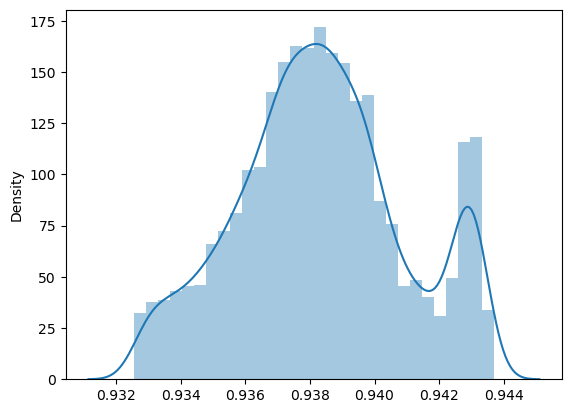

In [69]:
# Using Boxcox

aa,b=stats.boxcox(df['avg_glucose_level'])
stats.probplot(aa,dist='norm',plot=plt)
plt.show()
sns.distplot(aa)

-> After using Boxcox also it havent transformed compleetly into a guassian so lets use CLT

In [70]:
sample_means=[]
def clt_on_petal_length(data,size_of_sample,no_of_sample):
    for i in range(0,no_of_sample):
        samples=np.random.choice(data,size=size_of_sample)
        sample_means.append(np.mean(samples))
    return sample_means
clt_val=clt_on_petal_length(df['avg_glucose_level'],50,1000)

C:\Users\AKASH\AppData\Local\Temp\ipykernel_22944\1779298826.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clt_val)


<Axes: ylabel='Density'>

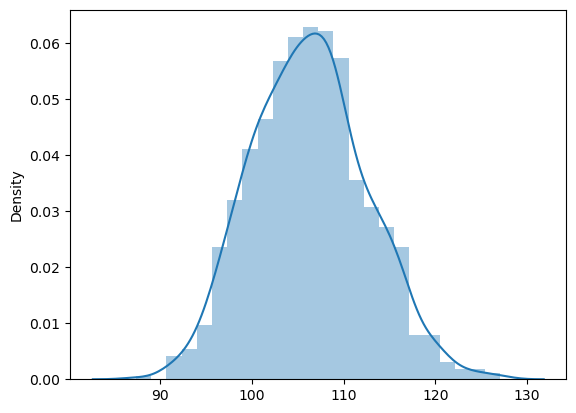

In [71]:
sns.distplot(clt_val)

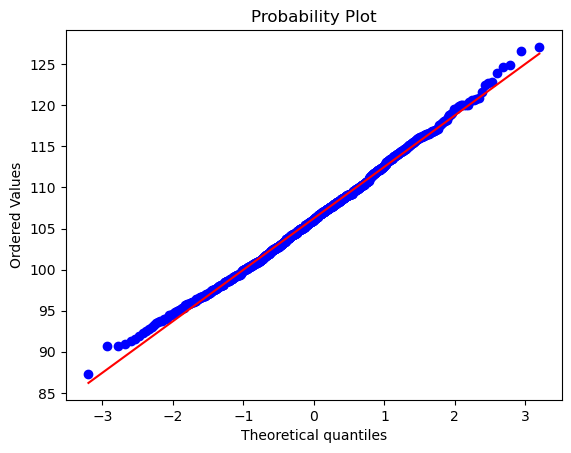

In [72]:
stats.probplot(clt_val,dist='norm',plot=plt)
plt.show()

Text(0, 0.5, 'Cummilative Frequency')

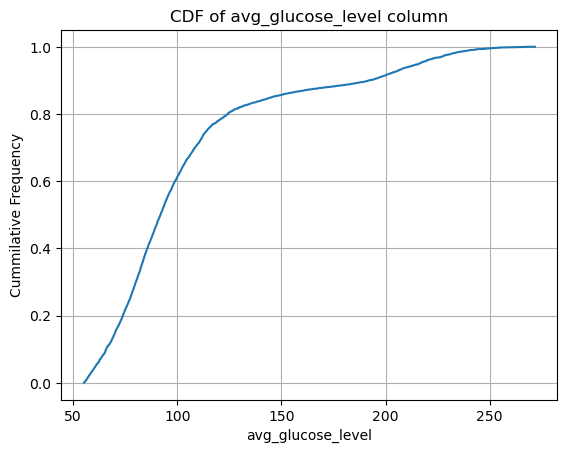

In [73]:
sorted_val=df['avg_glucose_level'].sort_values()
cdf_values=np.arange(1,len(sorted_val)+1)/len(sorted_val)

plt.plot(sorted_val,cdf_values)
plt.grid()
plt.title('CDF of avg_glucose_level column')
plt.xlabel('avg_glucose_level')
plt.ylabel('Cummilative Frequency')

<Axes: ylabel='avg_glucose_level'>

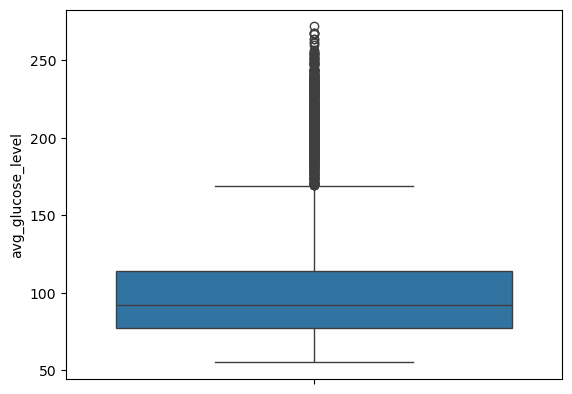

In [74]:
sns.boxplot(df['avg_glucose_level'])

### Univariate analysis on bmi

In [75]:
df['bmi'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5110 entries, 0 to 5109
Series name: bmi
Non-Null Count  Dtype  
--------------  -----  
4909 non-null   float64
dtypes: float64(1)
memory usage: 40.1 KB


#### statistical analysis on bmi

In [29]:
df['bmi'].isna().sum()

201

C:\Users\AKASH\AppData\Local\Temp\ipykernel_14340\4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

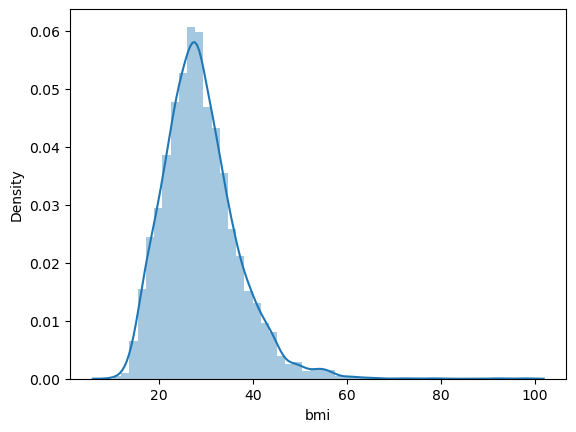

In [30]:
sns.distplot(df['bmi'])

In [31]:
df['bmi']=df['bmi'].fillna(np.mean(df['bmi']))

df['bmi'].isna().sum()

0

In [79]:
df['bmi'].mean()

28.893236911794663

In [80]:
df['bmi'].std()

7.698017826857077

In [81]:
df['bmi'].median()

28.4

In [82]:
df['bmi'].min()

10.3

In [83]:
df['bmi'].max()

97.6

-> this shows people having bmi in range between 10.3 to 97.6

In [84]:
percentiles=[0,10,25,50,75,90,95,99,100]

for i in percentiles:
    percentile_values=np.percentile(df['bmi'],i)
    print(f'{i}th Percentile Value : {percentile_values}')

0th Percentile Value : 10.3
10th Percentile Value : 19.89
25th Percentile Value : 23.8
50th Percentile Value : 28.4
75th Percentile Value : 32.8
90th Percentile Value : 38.7
95th Percentile Value : 42.65500000000002
99th Percentile Value : 52.890999999999984
100th Percentile Value : 97.6


#### Graphical analysis of bmi

C:\Users\AKASH\AppData\Local\Temp\ipykernel_22944\4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

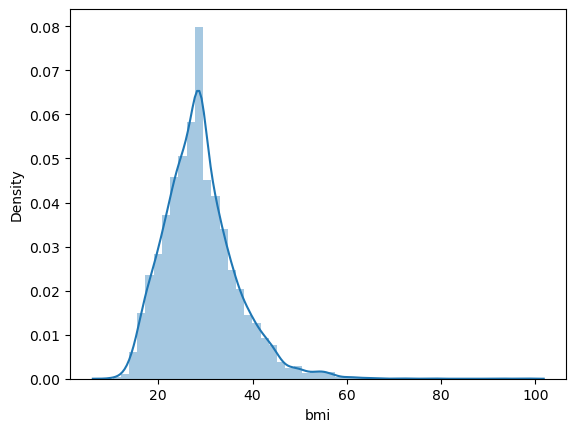

In [85]:
sns.distplot(df['bmi'])

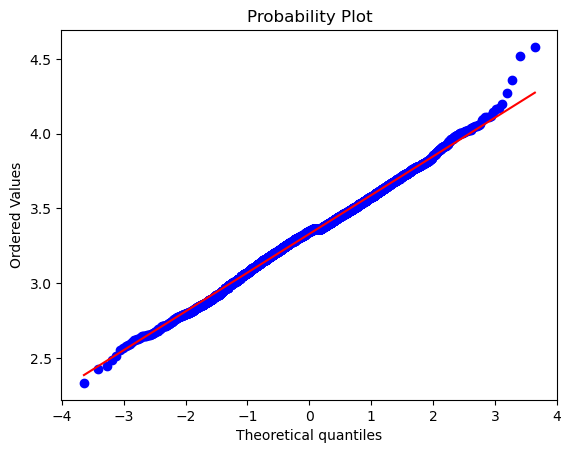

In [86]:
# looks like a little Right skew so,let apply log normal
a=np.log(df['bmi'])
stats.probplot(a,dist='norm',plot=plt)
plt.show()

C:\Users\AKASH\AppData\Local\Temp\ipykernel_22944\819221729.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a)


<Axes: xlabel='bmi', ylabel='Density'>

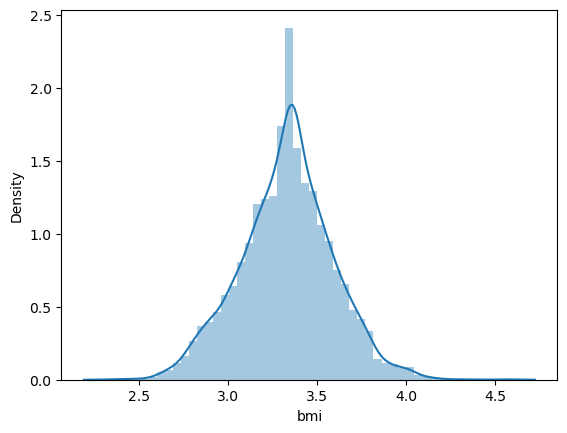

In [87]:
sns.distplot(a)

<Axes: ylabel='bmi'>

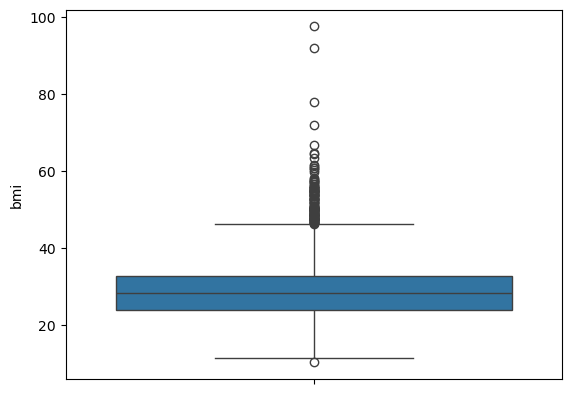

In [88]:
sns.boxplot(df['bmi'])

Text(0, 0.5, 'Cummilative Frequency')

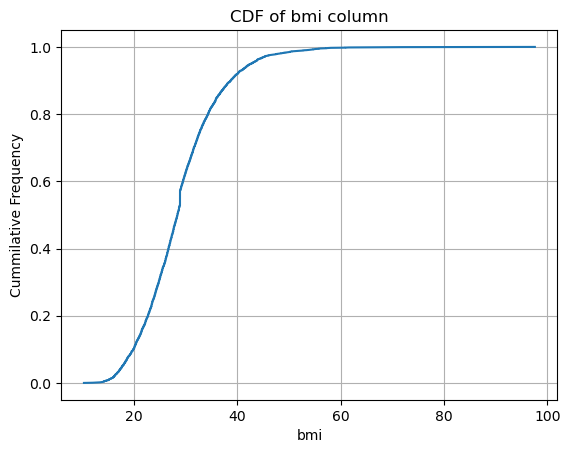

In [89]:
sorted_val=df['bmi'].sort_values()
cdf_values=np.arange(1,len(sorted_val)+1)/len(sorted_val)

plt.plot(sorted_val,cdf_values)
plt.grid()
plt.title('CDF of bmi column')
plt.xlabel('bmi')
plt.ylabel('Cummilative Frequency')

### Univariate analysis on smoking_status

In [90]:
df['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [91]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

<Axes: xlabel='smoking_status'>

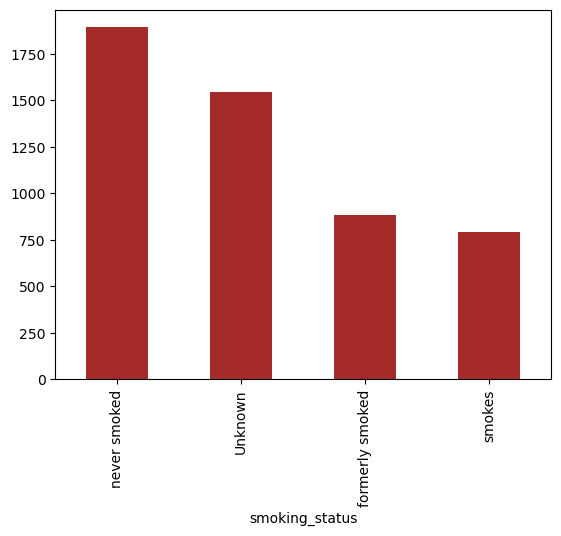

In [92]:
df['smoking_status'].value_counts().plot(kind='bar',color='BrowN')

In [93]:
a=df[(df['smoking_status']=='smokes')&(df['stroke']==1)].shape[0]
b=df[(df['smoking_status']=='never smoked')&(df['stroke']==1)].shape[0]
c=df[(df['smoking_status']=='formerly smoked')&(df['stroke']==1)].shape[0]
total=df.shape[0]

ss=(a/total)*100
sn=(b/total)*100
sf=(c/total)*100
print(ss,sn,sf)

0.821917808219178 1.761252446183953 1.36986301369863


#### Univariate analysis on stroke

In [94]:
df['stroke'].unique()

array([1, 0], dtype=int64)

<Axes: xlabel='stroke'>

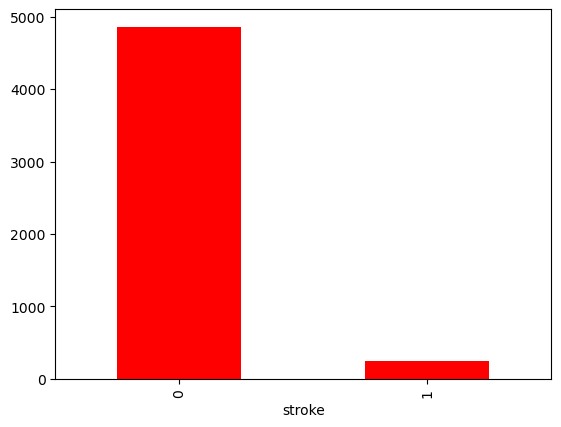

In [95]:
df['stroke'].value_counts().plot(kind='bar',color='red')

# Bivariate anlysis on Stroke data set

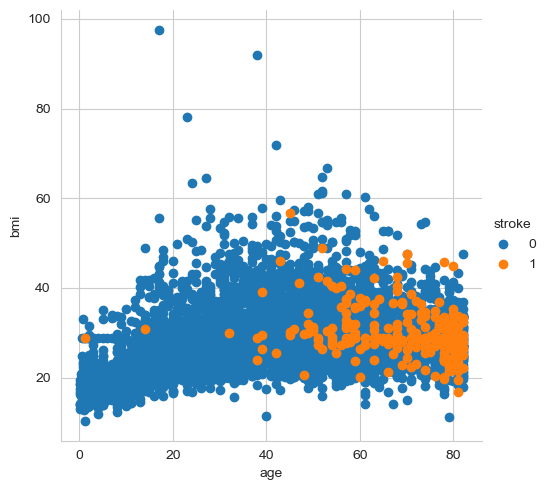

In [96]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue='stroke',height=5).map(plt.scatter,'age','bmi').add_legend()

In [32]:
stats.spearmanr(df['bmi'],df['age'])

SignificanceResult(statistic=0.363661456705788, pvalue=1.4023181328908246e-159)

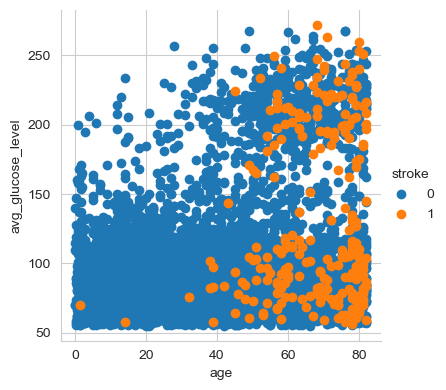

In [99]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue='stroke',height=4).map(plt.scatter,'age','avg_glucose_level').add_legend()

In [33]:
stats.spearmanr(df['avg_glucose_level'],df['age'])

SignificanceResult(statistic=0.1451677092953779, pvalue=1.8096446852948583e-25)

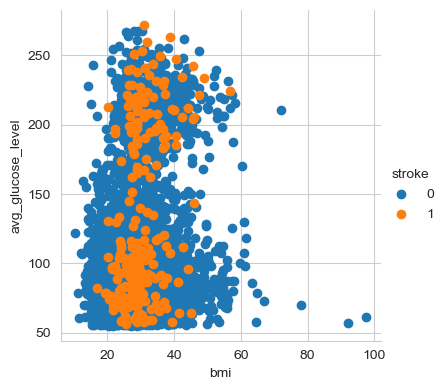

In [100]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue='stroke',height=4).map(plt.scatter,'bmi','avg_glucose_level').add_legend()

In [34]:
stats.spearmanr(df['avg_glucose_level'],df['bmi'])

SignificanceResult(statistic=0.11369630776085582, pvalue=3.580912687123695e-16)

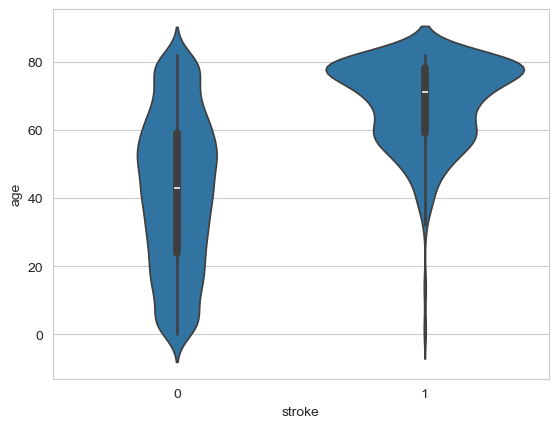

In [101]:
sns.violinplot(data=df, x='stroke', y='age')
plt.show()

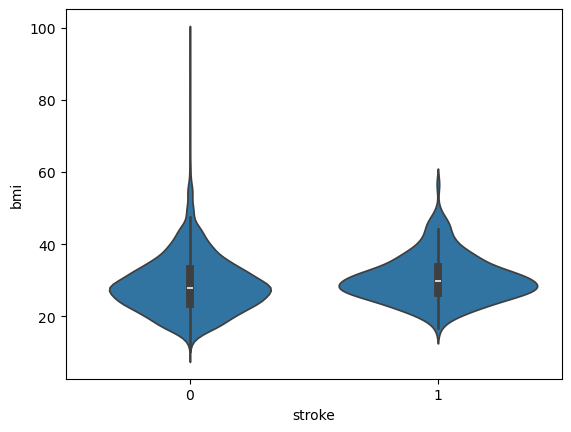

In [22]:
sns.violinplot(data=df,x='stroke',y='bmi')
plt.show()

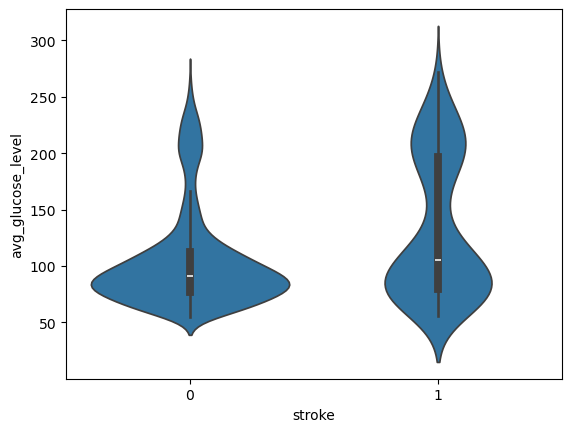

In [23]:
sns.violinplot(data=df,x='stroke',y='avg_glucose_level')
plt.show()

## Multivariate Analysis

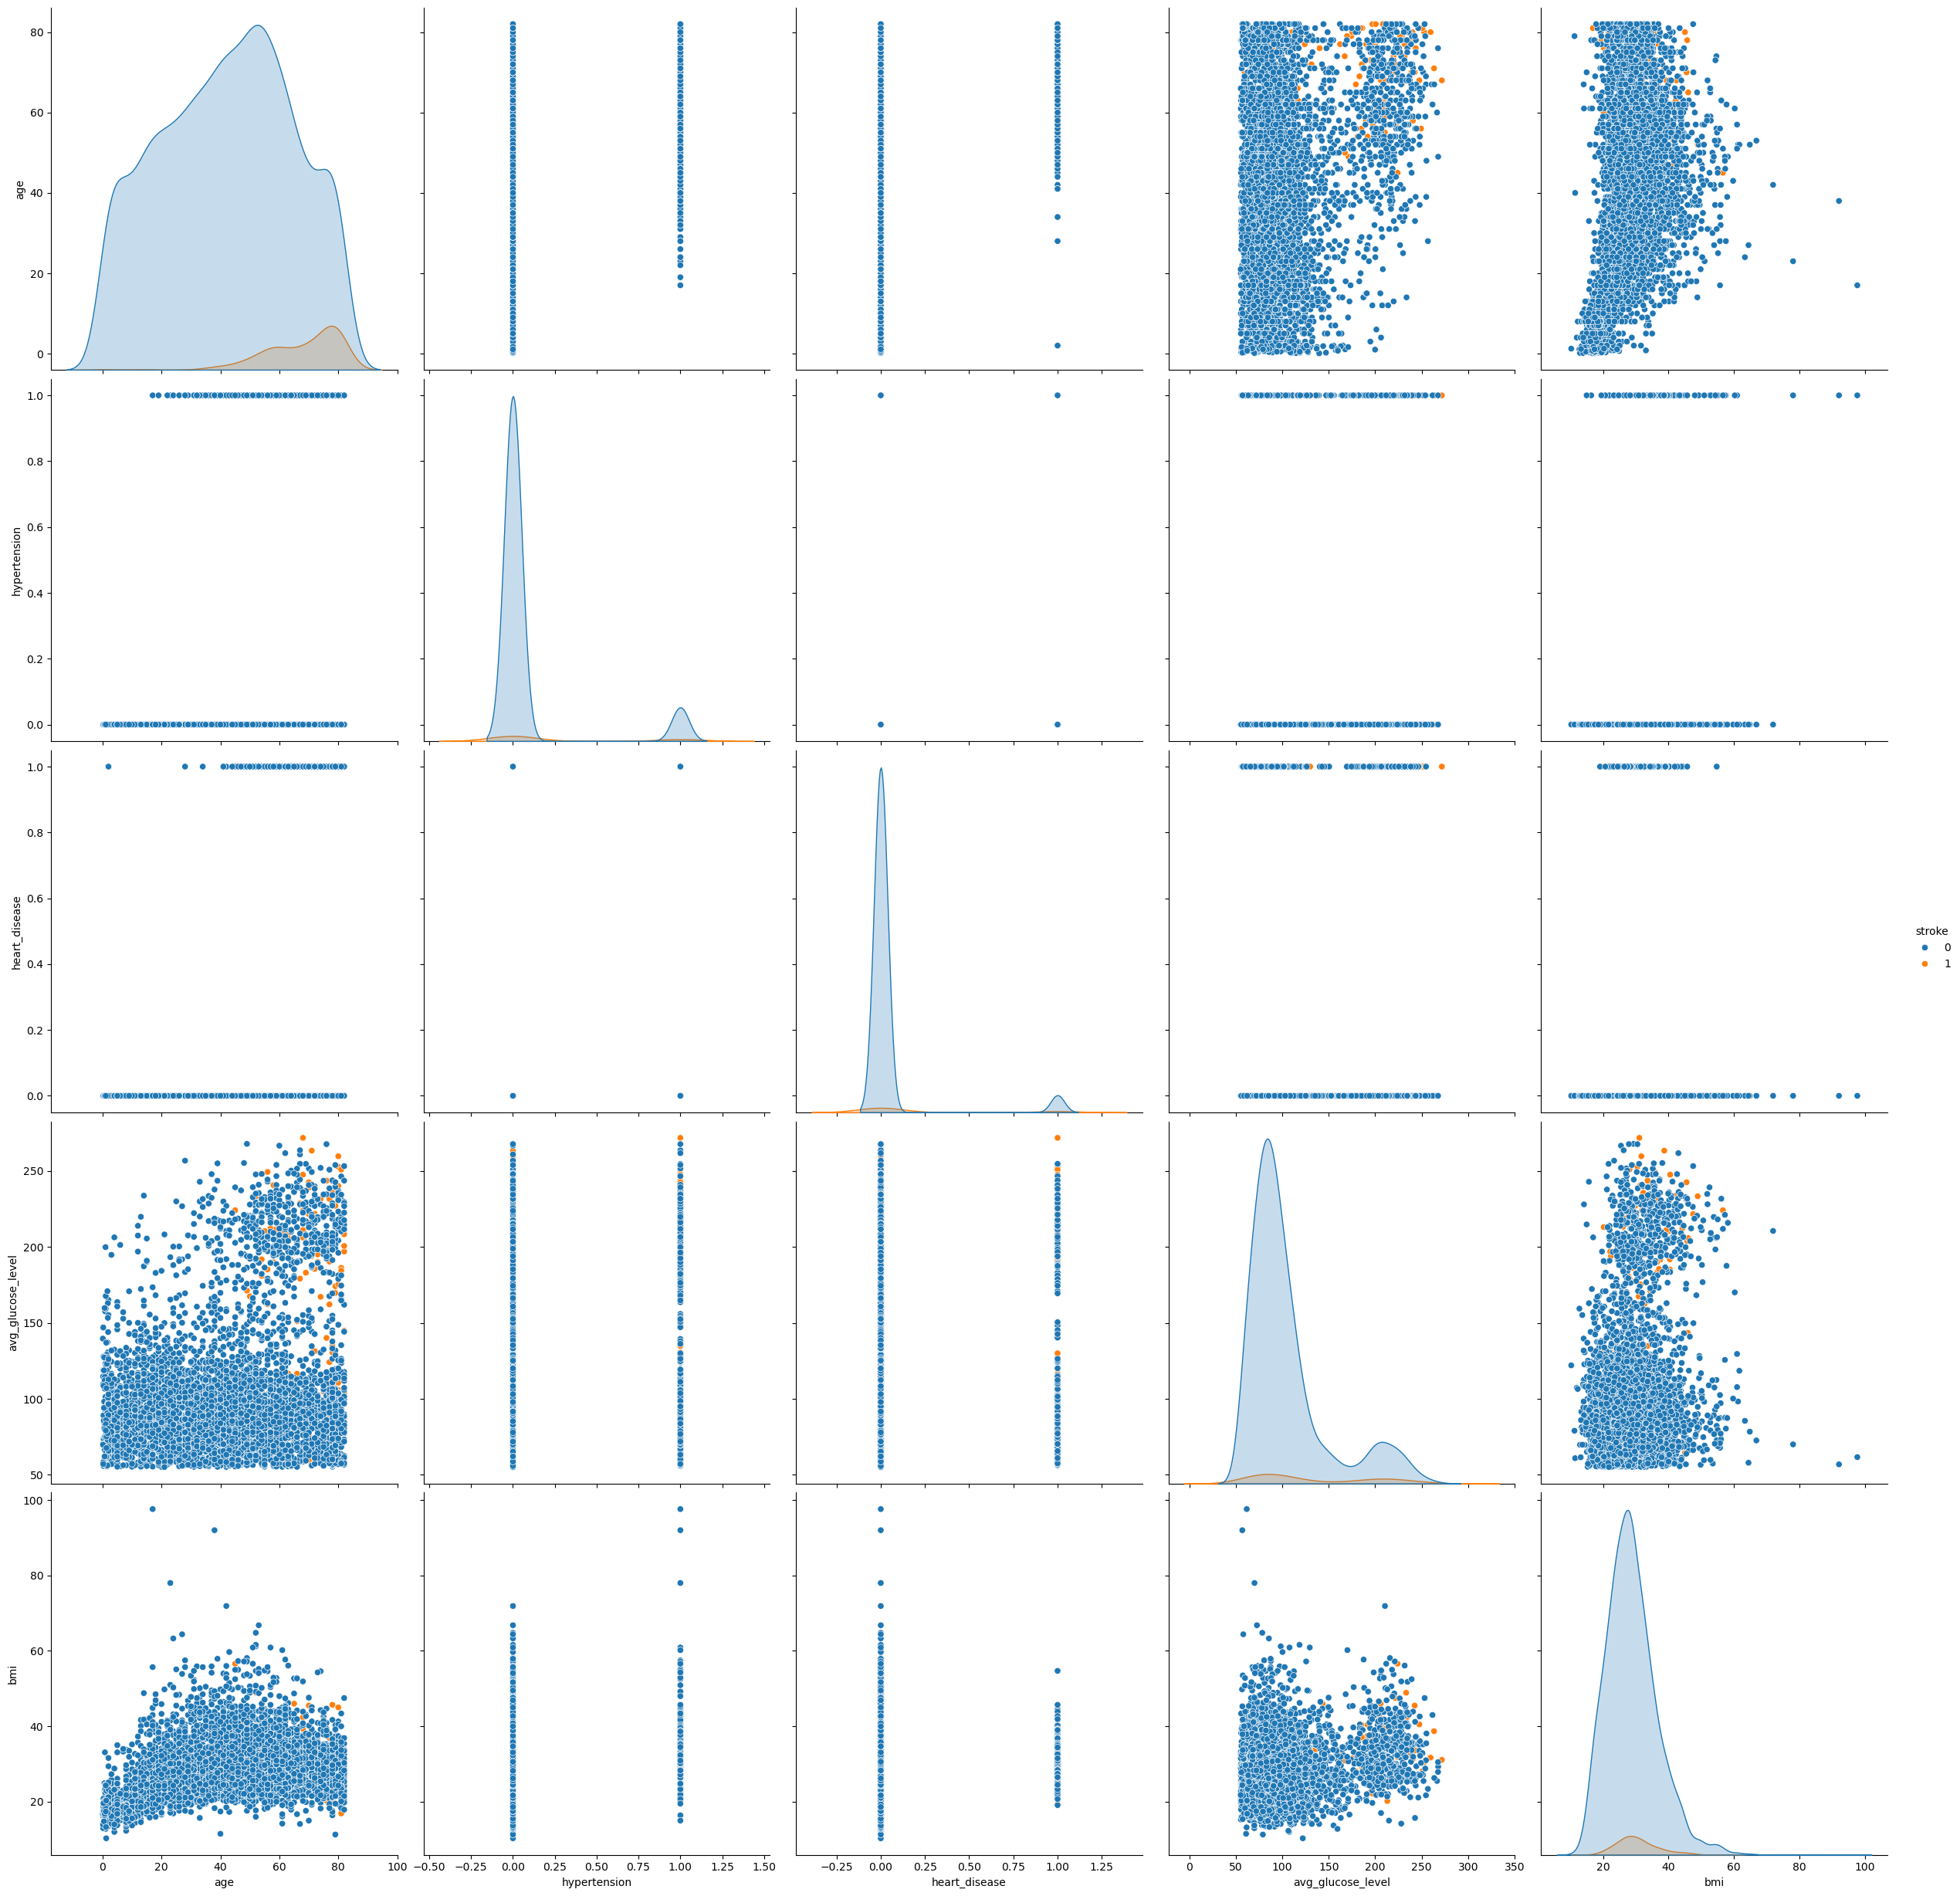

In [27]:
sns.pairplot(df,hue='stroke',height=5)

<Axes: >

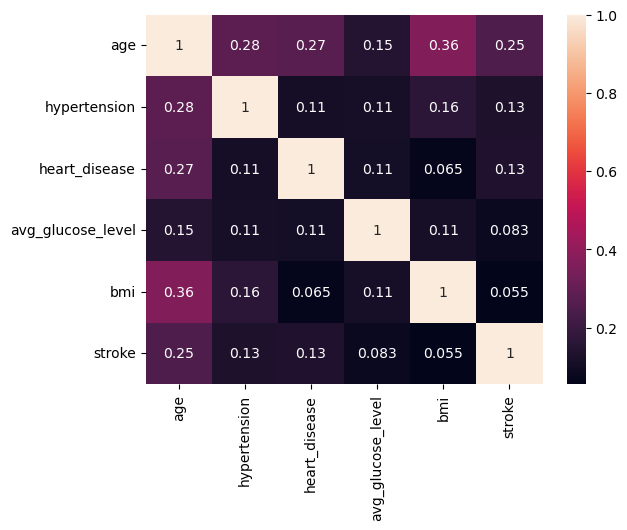

In [39]:
sns.heatmap(df.select_dtypes(include=['int','float64']).corr(method='spearman'),annot=True)

## Overall Analysis